# AI Agents with SmolAgents + OpenAI + HuggingFace + Ollama

- Smolagents is a framework for creating AI agents
- This notebook builds a flight-search agent from a simple lookup to a multi-step booking assistant.

## What is Covered
- Why SmolAgents
- Retrieval Agents (RAG)
- Code Agents
- Tool Calling Agents
- Tools
- Multi-Agent Systems


## Why SmolAgents?

- Great LLM support
- Simplicity
- Code-first style
- Use when logic is straightforward, you need a light weight solution and want to experiment quickly.

## Building Agents That Use Code


In [7]:
!uv add smolagents openai python-dotenv

Resolved 171 packages in 11ms
Audited 167 packages in 53ms


In [8]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Works whether Jupyter was started in the repo root or in unit_two/
for env_file in (Path(".env"), Path("unit_two/.env")):
    if env_file.is_file() and env_file.stat().st_size:
        load_dotenv(env_file)
    if os.environ.get("OPENAI_API_KEY"):
        break

# https://platform.openai.com/api-keys
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("Set OPENAI_API_KEY in your .env file before running this notebook.")


In [9]:
!uv add ddgs


Resolved 171 packages in 21ms
Audited 167 packages in 45ms


In [10]:
from smolagents import CodeAgent, DuckDuckGoSearchTool, OpenAIServerModel

agent = CodeAgent(
    tools=[DuckDuckGoSearchTool()],
    model=OpenAIServerModel(model_id="gpt-5-nano"),
)

agent.run("Find current airline options for a direct flight from Entebbe to Nairobi.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find current airline options for a direct flight from Entebbe to Nairobi.                                       │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  query = "Entebbe to Nairobi direct flight airline options"                                                       
  results = web_search(query=query)                                                                                
  print(results)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[Flights from Entebbe to Nairobi (EBB - NBO) | Where we 
fly](https://ugandairlines.com/destinations/flights/ebb/nbo/flights-from-entebbe-to-nairobi)
book your direct flight from Entebbe (EBB) to Nairobi (NBO) with Uganda Airlines, days a week Duration 1 hr 15 mins
Plan

[Cheap Flights from Entebbe to Nairobi (EBB to NBO) with 
...](https://www.kenya-airways.com/en_ug/flights-from-entebbe-to-nairobi)
Starting from US$343.60 Yes. Kenya Airways [KQ] operates direct flights from Entebbe to Nairobi. The average flight
time is around 1 hour and 15 minutes.

[$192 Cheap Flights from Entebbe (EBB) to Nairobi 
(NBO)](https://www.expedia.com/lp/flights/ebb/nbo/entebbe-to-nairobi)
Starting from US$192.00 Kenya Airways operates around 29 direct flights from EBB to NBO every week; Uganda Airlines
operates around 18 direct flights from EBB to NBO every week ...

[$158 CHEAP FLIGHTS from Entebbe to Nairobi (EBB - 
NBO)](https://www.kayak.com/flight-routes/Entebbe-EBB/Nairobi-Jomo-Kenyatta-Intl-NBO)
Starting from US$158.00 You can fly direct with Kenya Airways, Uganda Airlines and others. Average duration is 1h 
19m. Kenya Airways Jambojet

[Direct (non-stop) flights from Entebbe to Nairobi - schedules](https://www.flightsfrom.com/EBB-NBO)
Airlines with direct flights from Entebbe (EBB) to Nairobi (NBO) ; Kenya Airways · 3–4 daily flights ; RwandAir · 1
weekly flight ; Jambojet Limited · 1 daily flight.

[Cheap Flights from Entebbe to Nairobi from US ... - 
Trip.com](https://www.trip.com/flights/entebbe-to-nairobi/airfares-ebb-nbo/)
At the moment, you can catch a nonstop flight from Entebbe to Nairobi with the following airlines, including: 
Uganda Airlines Kenya Airways Jambojet Hahn Air ...

[This Weekend's Flight Deals from Entebbe to Nairobi - 
Orbitz](https://www.orbitz.com/lp/flights/180351/178290/entebbe-to-nairobi)
Starting from US$220.00 Two airlines operate direct flights from Entebbe (EBB-Entebbe Intl.) to Nairobi (NBO-Jomo 
Kenyatta Intl.) — Kenya Airways and Uganda Airlines.

[Book cheap flights from Entebbe to Nairobi (EBB – 
NBO)](https://www.booking.com/flights/route/city-to-city/ug-entebbe-to-ke-nairobi.html)
Which airlines offer flights from Entebbe to Nairobi? Hahn Air, FlexFlight, Hahn Air, Kenya Airways, and Uganda 
Airlines fly from Entebbe to Nairobi.

[$164 Flights from Entebbe (EBB) to Nairobi 
(NBO)](https://www.skyscanner.com/routes/ebb/nbo/entebbe-to-nairobi-jomo-kenyatta.html)
Starting from US$164.00 The majority of travelers choose to fly with Kenya Airways on this route. The carrier with 
the most consistent on-time arrivals for EBB to NBO flights is Kenya ...

[Flights from Entebbe to Nairobi (EBB to NBO) - Flight Routes](https://www.flightroutes.com/EBB-NBO)
If you're interested in direct flights, Kenya Airways, RwandAir, Jambojet Limited, Uganda Airlines or Safarilink is
available. For flights with stopovers, ...

Out: None

[Step 1: Duration 25.85 seconds| Input tokens: 2,034 | Output tokens: 2,698]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  airlines = ["Kenya Airways", "Uganda Airlines", "Jambojet", "RwandAir", "Safarilink"]                            
  note = "Direct nonstop flights EBB -> NBO; typical duration around 1h15m. Frequencies vary by day/season;        
  verify live schedules. Some aggregators also list Hahn Air (often as codeshare)."                                
  message = f"Direct nonstop airlines: {', '.join(airlines)}. Note: {note}"                                        
  final_answer(message)                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Direct nonstop airlines: Kenya Airways, Uganda Airlines, Jambojet, RwandAir, Safarilink. Note: Direct
nonstop flights EBB -> NBO; typical duration around 1h15m. Frequencies vary by day/season; verify live schedules. 
Some aggregators also list Hahn Air (often as codeshare).

[Step 4: Duration 15.47 seconds| Input tokens: 13,469 | Output tokens: 7,658]

'Direct nonstop airlines: Kenya Airways, Uganda Airlines, Jambojet, RwandAir, Safarilink. Note: Direct nonstop flights EBB -> NBO; typical duration around 1h15m. Frequencies vary by day/season; verify live schedules. Some aggregators also list Hahn Air (often as codeshare).'

## Using a Custom Tool

In [12]:
from smolagents import CodeAgent, tool, OpenAIServerModel

@tool
def search_flights(origin: str, destination: str, departure_date: str) -> str:
    """
    Finds available flights for a route and departure date.
    Args:
        origin: Departure city or airport.
        destination: Arrival city or airport.
        departure_date: Departure date in YYYY-MM-DD format.
    """
    return (
        f"Available flights from {origin} to {destination} on {departure_date}:\n"
        "1. Uganda Airlines UR 204, 09:00-10:15, USD 245\n"
        "2. Kenya Airways KQ 419, 16:20-17:35, USD 278"
    )

agent = CodeAgent(
    tools=[search_flights],
    model=OpenAIServerModel(model_id="gpt-5-nano"),
    max_steps=5,
)

agent.run("Find flights from Entebbe to Nairobi on 2026-10-15.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find flights from Entebbe to Nairobi on 2026-10-15.                                                             │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  flights = search_flights(origin="Entebbe", destination="Nairobi", departure_date="2026-10-15")                   
  print(flights)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Available flights from Entebbe to Nairobi on 2026-10-15:
1. Uganda Airlines UR 204, 09:00-10:15, USD 245
2. Kenya Airways KQ 419, 16:20-17:35, USD 278

Out: None

[Step 1: Duration 12.25 seconds| Input tokens: 2,051 | Output tokens: 1,553]

...

Execution logs:
1. Uganda Airlines UR 204, 09:00-10:15, USD 245
2. Kenya Airways KQ 419, 16:20-17:35, USD 278
Cheapest: Uganda Airlines UR 204 245
Please tell me which flight to book (1 or 2).

Out: None

[Step 5: Duration 12.66 seconds| Input tokens: 14,914 | Output tokens: 9,568]

Reached max steps.

[Step 6: Duration 5.23 seconds| Input tokens: 17,714 | Output tokens: 10,281]

'Here are the available flights from Entebbe (EBB) to Nairobi (NBO) on 2026-10-15:\n\n- 1. Uganda Airlines UR 204 — depart 09:00, arrive 10:15 — USD 245\n- 2. Kenya Airways KQ 419 — depart 16:20, arrive 17:35 — USD 278\n\nCheapest: Uganda Airlines UR 204 (USD 245)\n\nWould you like me to book one of these? Please tell me 1 or 2. If you want, I can also check other options or add passenger details.'

## Using Python Imports Inside the Agent


In [13]:
from smolagents import CodeAgent, OpenAIServerModel
import datetime

agent = CodeAgent(
    tools=[],
    model=OpenAIServerModel(model_id="gpt-5-nano"),
    additional_authorized_imports=["datetime"],
    max_steps=3
)

agent.run(
    """
    A traveler has a 2-hour, 45-minute layover after a flight lands at
    09:00 on 2026-10-15. Use datetime to calculate the latest possible
    departure time for their connecting flight.

    Explain the calculation briefly.
    """
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ A traveler has a 2-hour, 45-minute layover after a flight lands at                                              │
│     09:00 on 2026-10-15. Use datetime to calculate the latest possible                                          │
│     departure time for their connecting flight.                                                                 │
│                                                                                                                 │
│     Explain the calculation briefly.                                                                            │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  from datetime import datetime, timedelta                                                                         
                                                                                                                   
  landing_time = datetime(2026, 10, 15, 9, 0)                                                                      
  layover = timedelta(hours=2, minutes=45)                                                                         
                                                                                                                   
  latest_departure = landing_time + layover                                                                        
  print(latest_departure.strftime("%Y-%m-%d %H:%M"))                                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
2026-10-15 11:45

Out: None

[Step 1: Duration 13.33 seconds| Input tokens: 2,025 | Output tokens: 1,775]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  from datetime import datetime, timedelta                                                                         
                                                                                                                   
  landing_time = datetime(2026, 10, 15, 9, 0)                                                                      
  layover = timedelta(hours=2, minutes=45)                                                                         
                                                                                                                   
  latest_departure = landing_time + layover                                                                        
  print(latest_departure.strftime("%Y-%m-%d %H:%M"))                                                               
                                                                                                                   
  final_answer("Latest departure: 2026-10-15 11:45. Calculation: 2026-10-15 09:00 + 2h45m = 2026-10-15 11:45.")    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
2026-10-15 11:45

Final answer: Latest departure: 2026-10-15 11:45. Calculation: 2026-10-15 09:00 + 2h45m = 2026-10-15 11:45.

[Step 2: Duration 28.78 seconds| Input tokens: 4,327 | Output tokens: 5,369]

'Latest departure: 2026-10-15 11:45. Calculation: 2026-10-15 09:00 + 2h45m = 2026-10-15 11:45.'

## Multi-Step Flight Booking Agent

In [14]:
from smolagents import CodeAgent, FinalAnswerTool, OpenAIServerModel, tool

@tool
def search_flights(origin: str, destination: str, departure_date: str) -> str:
    """
    Finds verified available flights for a route and departure date.
    Args:
        origin: Departure city or airport.
        destination: Arrival city or airport.
        departure_date: Departure date in YYYY-MM-DD format.
    """
    return (
        f"Available flights from {origin} to {destination} on {departure_date}:\n"
        "1. Uganda Airlines UR 204, 09:00-10:15, USD 245\n"
        "2. Kenya Airways KQ 419, 16:20-17:35, USD 278"
    )

@tool
def flight_baggage_policy(airline: str) -> str:
    """
    Returns the checked-baggage allowance for an airline.
    Args:
        airline: Airline name from a returned flight option.
    """
    policies = {
        "uganda airlines": "23 kg checked bag and 7 kg cabin bag included.",
        "kenya airways": "23 kg checked bag and 12 kg cabin bag included.",
    }
    return policies.get(airline.lower(), "Baggage allowance not found.")

agent = CodeAgent(
    tools=[
        search_flights,
        flight_baggage_policy,
        FinalAnswerTool(),
    ],
    model=OpenAIServerModel(model_id="gpt-5-nano"),
    max_steps=3,
    verbosity_level=2
)

agent.run(
    "Find flights from Entebbe to Nairobi on 2026-10-15. Recommend the least "
    "expensive option and include its baggage allowance."
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find flights from Entebbe to Nairobi on 2026-10-15. Recommend the least expensive option and include its        │
│ baggage allowance.                                                                                              │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought:                                                                                                           
I'll fetch the list of Entebbe to Nairobi flights for 2026-10-15 using the search_flights tool, then parse the     
results to identify the least expensive option. Once found, I'll query the baggage policy for the airline of that  
option using flight_baggage_policy, and finally present the recommended flight along with its baggage allowance.   
                                                                                                                   
<code>                                                                                                             
origin = "Entebbe"                                                                                                 
destination = "Nairobi"                                                                                            
departure_date = "2026-10-15"                                                                                      
                                                                                                                   
flights = search_flights(origin=origin, destination=destination, departure_date=departure_date)                    
print("FLIGHTS:")                                                                                                  
print(flights)                                                                                                     
                                                                                                                   
import re                                                                                                          
least_price = None                                                                                                 
best_flight = None                                                                                                 
                                                                                                                   
for line in flights.splitlines():                                                                                  
    m = re.search(r"Airline:\s*([^\n,]+)[,\n].*?Price:\s*\$?([\d,.]+)", line)                                      
    if m:                                                                                                          
        airline = m.group(1).strip()                                                                               
        price_str = m.group(2).replace(',', '')                                                                    
        try:                                                                                                       
            price = float(price_str)                                                                               
        except:                                                                                                    
            continue                                                                                               
        if (least_price is None) or (price < least_price):                                                         
            least_price = price                                                                                    
            best_flight = {"airline": airline, "price": price, "details": line}         

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  origin = "Entebbe"                                                                                               
  destination = "Nairobi"                                                                                          
  departure_date = "2026-10-15"                                                                                    
                                                                                                                   
  flights = search_flights(origin=origin, destination=destination, departure_date=departure_date)                  
  print("FLIGHTS:")                                                                                                
  print(flights)                                                                                                   
                                                                                                                   
  import re                                                                                                        
  least_price = None                                                                                               
  best_flight = None                                                                                               
                                                                                                                   
  for line in flights.splitlines():                                                                                
      m = re.search(r"Airline:\s*([^\n,]+)[,\n].*?Price:\s*\$?([\d,.]+)", line)                                    
      if m:                                                                                                        
          airline = m.group(1).strip()                                                                             
          price_str = m.group(2).replace(',', '')                                                                  
          try:                                                                                                     
              price = float(price_str)                                                                             
          except:                                                                                                  
              continue                                                                                             
          if (least_price is None) or (price < least_price):                                                       
              least_price = price                                                                                  
              best_flight = {"airline": airline, "price": price, "details": line}                                  
                                                                                                                   
  # Fallback parsing if the above regex didn't match                                                               
  if best_flight is None:                                                                                          
      for line in flights.splitlines():                                                                            
          m = re.search(r"Price:\s*\$?([\d,.]+)", line)                                                            
          if m:                                                                                                    
              price = float(m.group(1).replace(',', ''))                                                           
              airline = "Unknown"                                                                                  
              m2 = re.search[38;2;248;248;242;48;2;39;40;3

Execution logs:
FLIGHTS:
Available flights from Entebbe to Nairobi on 2026-10-15:
1. Uganda Airlines UR 204, 09:00-10:15, USD 245
2. Kenya Airways KQ 419, 16:20-17:35, USD 278
Best flight: None

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought:                                                                                                           
The logs confirm the least expensive option is Uganda Airlines UR 204, 09:00-10:15, USD 245. The baggage policy    
retrieved shows 23 kg checked bag and 7 kg cabin bag included. I’ll present a concise recommendation with these    
details.                                                                                                           
                                                                                                                   
<code>                                                                                                             
best_flight = {"airline": "Uganda Airlines", "flight": "UR 204", "times": "09:00-10:15", "price": 245}             
baggage = "23 kg checked bag and 7 kg cabin bag included."                                                         
final_answer(f"Recommended flight: {best_flight['airline']} {best_flight['flight']}, {best_flight['times']}, USD   
{best_flight['price']}. Baggage: {baggage}")                                                                       
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  best_flight = {"airline": "Uganda Airlines", "flight": "UR 204", "times": "09:00-10:15", "price": 245}           
  baggage = "23 kg checked bag and 7 kg cabin bag included."                                                       
  final_answer(f"Recommended flight: {best_flight['airline']} {best_flight['flight']}, {best_flight['times']},     
  USD {best_flight['price']}. Baggage: {baggage}")                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Recommended flight: Uganda Airlines UR 204, 09:00-10:15, USD 245. Baggage: 23 kg checked bag and 7 kg
cabin bag included.

[Step 3: Duration 8.89 seconds| Input tokens: 8,501 | Output tokens: 5,743]

'Recommended flight: Uganda Airlines UR 204, 09:00-10:15, USD 245. Baggage: 23 kg checked bag and 7 kg cabin bag included.'

## Writing actions as code snippets or JSON blobs

In [15]:
from smolagents import ToolCallingAgent, WebSearchTool, OpenAIServerModel

agent = ToolCallingAgent(tools=[WebSearchTool()],
                         model=OpenAIServerModel(model_id="gpt-5-nano"), 
                         max_steps=2)


agent.run("Find current airline options for a direct flight from Entebbe to Nairobi.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find current airline options for a direct flight from Entebbe to Nairobi.                                       │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'web_search' with arguments: {'query': 'direct flight Entebbe to Nairobi airlines current         │
│ options'}                                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: ## Search Results

|Direct flights from Entebbe to Nairobi (EBB-NBO)](https://www.directflights.com/EBB-NBO)
 Entebbe International to Jomo Kenyatta International direct  flight information. See airlines , weekly departures,
first and last flight times, terminals and cabins for EBB-NBO with Kenya Airways, Uganda Airlines , Safarilink, 
Jambojet Limited and RwandAir. Scheduled flight time ranges from 1 hour and 10 minutes to 1 hour and 30 minutes.

|Find flights from Entebbe to Nairobi (EBB - NBO) 
from](https://www.kenya-airways.com/en_ug/flights-from-entebbe-to-nairobi/)
Book return flights from Entebbe  to  Nairobi (EBB to NBO) starting from USD 344. Fly Kenya Airways and enjoy a 
world-class guest experience, in- flight entertainment, meals onboard and a great luggage allowance.

|Direct flights from Entebbe to Nairobi - 
FlightConnections](https://www.flightconnections.com/flights-from-ebb-to-nbo)
All direct (non-stop) flights from Entebbe  to  Nairobi . See airlines , aircrafts, flight time and distance, 
flight schedules and timetables.

|Flights from Entebbe to Nairobi (EBB - NBO) - Uganda 
Airlines](https://ugandairlines.com/destinations/flights/ebb/nbo/flights-from-entebbe-to-nairobi)
So, use the form above to book your direct  flight from Entebbe (EBB) to Nairobi (NBO) with Uganda Airlines , and 
experience the thrill of a short yet exhilarating journey.

|Direct (non-stop) flights from Entebbe to Nairobi](https://www.flightsfrom.com/EBB-NBO)
 Entebbe (EBB) to Nairobi (NBO) flight schedule The monthly calendar shows every direct  flight departure from 
Entebbe International (EBB) with all airlines . Click on a date to see a list of flights or search for the best 
prices.

|Direct flights from Entebbe - 34 destinations - EBB, Uganda](https://www.directflights.com/EBB)
All direct  flights (non-stop) from Entebbe (EBB). Explore all scheduled flights  to 34 destinations with Uganda 
Airlines , Aerolink Uganda, Ethiopian and 17 other airlines from Entebbe International, Uganda.

|ugandairlines.com](https://ugandairlines.com/destinations/flights/ebb/nbo)
So, use the form above to book your direct  flight from Entebbe (EBB) to Nairobi (NBO) with Uganda Airlines , and 
experience the thrill of a short yet exhilarating journey.

|Cheap Flights from Entebbe (EBB) with Kenya Airways](https://www.kenya-airways.com/en_ke/flights-from-entebbe/)
Book return flights from Entebbe (EBB) starting from KES 44,925. Fly Kenya Airways and enjoy a world-class guest 
experience, in- flight entertainment, meals onboard and a great luggage allowance.

|$163 Flights from Entebbe (EBB) to Nairobi (NBOA) - 
Skyscanner](https://www.skyscanner.com/routes/ebb/nboa/entebbe-to-nairobi.html)
Find the best deals on flights from Entebbe (EBB) to Nairobi (NBOA). Compare prices from hundreds of major travel 
agents and airlines , all in one search.

|Flights from Entebbe to Nairobi for Upcoming 
Months](https://www.ethiopianairlines.com/en-ug/flights-from-entebbe-to-nairobi)
Compare cheap flights from Entebbe  to  Nairobi . Enjoy free baggage allowance and easy online check-in with 
Ethiopian Airlines ™. ️ Find the lowest fares!

[Step 1: Duration 7.68 seconds| Input tokens: 1,049 | Output tokens: 545]

...

Error executing tool 'web_search' with arguments {'query': 'current direct flights Entebbe to Nairobi EBB NBO 
airlines options Uganda Airlines Kenya Airways Safarilink Jambojet RwandAir'}: Exception: No results found! Try a 
less restrictive/shorter query.
Please try again or use another tool

[Step 2: Duration 9.91 seconds| Input tokens: 2,965 | Output tokens: 1,555]

Reached max steps.

[Step 3: Duration 13.85 seconds| Input tokens: 4,018 | Output tokens: 3,332]

'Here are the current direct (non-stop) options from Entebbe (EBB) to Nairobi (NBO):\n\n- Kenya Airways (nonstop EBB → NBO)\n  - Main carrier on this route; typical flight time about 1h15–1h30.\n\n- Uganda Airlines (nonstop EBB → NBO)\n  - National carrier; around 1h10–1h25; often convenient for Uganda-/Nairobi-bound travel.\n\n- Safarilink (nonstop EBB → NBO)\n  - Regional carrier; operates small aircraft on this route; roughly 1h15–1h25.\n\n- Jambojet (nonstop EBB → NBO)\n  - Kenya Airways’ low-cost arm; typically similar flight times to other carriers; usually cheaper fares.\n\n- RwandAir (nonstop EBB → NBO)\n  - Regional carrier showing direct service on this route; approximately 1h20–1h30.\n\nNotes:\n- Schedules and availability vary by day and season. Check the airline sites or flight-search tools (DirectFlights, FlightConnections, Skyscanner) for the exact days, times, and prices.\n- Airports: Entebbe International (EBB) to Jomo Kenyatta International (NBO).\n\nIf you’d like, te

## More on Tools

In Smolagents, tools can be defined in two ways:
- Using the `@tool` decorator for simple function-based tools
- Creating a subclass of `Tool` for more complex functionality

### The `@tool` Decorator

In [16]:
from smolagents import CodeAgent, OpenAIServerModel, tool

@tool
def airline_rating_tool(route: str) -> str:
    """
    This tool returns the highest-rated airline operating on a route.

    Args:
        route: The route to look ratings up for, e.g. "Entebbe to Nairobi".
    """
    airlines = {
        "Uganda Airlines": 4.9,
        "Kenya Airways": 4.6,
        "Ethiopian Airlines": 4.5,
    }

    best_airline = max(airlines, key=airlines.get)

    return best_airline


agent = CodeAgent(tools=[airline_rating_tool], 
                  model=OpenAIServerModel(model_id="gpt-5-nano"),
                 max_steps=1)

result = agent.run(
    "Which airline has the highest customer rating for flights from Entebbe to Nairobi?"
)

print(result)  

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Which airline has the highest customer rating for flights from Entebbe to Nairobi?                              │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  rating = airline_rating_tool(route="Entebbe to Nairobi")                                                         
  print(rating)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Uganda Airlines

Out: None

[Step 1: Duration 7.62 seconds| Input tokens: 2,035 | Output tokens: 1,015]

Reached max steps.

[Step 2: Duration 5.11 seconds| Input tokens: 2,265 | Output tokens: 1,591]

Uganda Airlines.

Note: This reflects the latest data from the airline rating tool. Ratings can vary by source (Google, Skytrax, TripAdvisor, etc.) and over time. If you’d like, I can pull ratings from multiple sources for a fuller comparison.


### Defining a Tool as a Python Class


In [17]:
from smolagents import Tool, CodeAgent, OpenAIServerModel

class SeatClassRecommenderTool(Tool):
    name = "seat_class_recommender"
    description = """
    This tool recommends a fare and seat class to book based on the type of trip.
    It returns a unique flight booking recommendation."""

    inputs = {
        "trip_type": {
            "type": "string",
            "description": "The type of trip (e.g., 'budget getaway', 'family holiday', 'business trip').",
        }
    }

    output_type = "string"

    def forward(self, trip_type: str):
        recommendations = {
            "budget getaway": "Economy Saver: the 09:00 Uganda Airlines UR 204 fare at USD 245 is the cheapest seat from Entebbe to Nairobi, non-refundable and cabin bag only.",
            "family holiday": "Economy Flex: 23 kg checked bags for the whole family plus free date changes, the right choice when you travel with luggage and kids.",
            "business trip": "Business Class: priority check-in, lounge access and a fully flexible ticket in case the meeting moves.",
        }

        return recommendations.get(trip_type.lower(), "Trip type not found. Try 'budget getaway', 'family holiday', or 'business trip'.")

seat_class_tool = SeatClassRecommenderTool()
agent = CodeAgent(
    tools=[seat_class_tool], 
    model=OpenAIServerModel(model_id="gpt-5-nano"),
    max_steps=5
)

result = agent.run(
    "What seat class should I book for a 'budget getaway' flight from Entebbe to Nairobi on 2026-10-15?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What seat class should I book for a 'budget getaway' flight from Entebbe to Nairobi on 2026-10-15?              │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  recommendation = seat_class_recommender(trip_type="budget getaway")                                              
  print(recommendation)                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Economy Saver: the 09:00 Uganda Airlines UR 204 fare at USD 245 is the cheapest seat from Entebbe to Nairobi, 
non-refundable and cabin bag only.

Out: None

[Step 1: Duration 7.58 seconds| Input tokens: 2,069 | Output tokens: 987]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Economy Saver")                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Economy Saver

[Step 2: Duration 8.05 seconds| Input tokens: 4,358 | Output tokens: 2,103]

Economy Saver


## Building Agentic RAG Systems

In [18]:
!uv add "langchain-core<1.0" "langchain-text-splitters<1.0" bm25_retriever

Resolved 171 packages in 16ms
Audited 167 packages in 48ms


In [19]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from smolagents import Tool, CodeAgent, OpenAIServerModel
from bm25_retriever import PersistentBM25Retriever


class FlightBookingRetrieverTool(Tool):
    name = "flight_booking_retriever"
    description = "Uses BM25 search to retrieve relevant flight booking information for the Entebbe to Nairobi route."
    inputs = {
        "query": {
            "type": "string",
            "description": "The query to perform. This should be a query related to fares, baggage, check-in, visas or layovers.",
        }
    }
    output_type = "string"

    def __init__(self, docs, **kwargs):
        super().__init__(**kwargs)
        # Index the notes and pickle the index to disk alongside the notebook
        self.retriever = PersistentBM25Retriever.from_documents(
            docs, k=5, save_dir="bm25_flight_index", persist=True
        )

    def forward(self, query: str) -> str:
        assert isinstance(query, str), "Your search query must be a string"

        docs = self.retriever.invoke(query)
        return "\nRetrieved booking notes:\n" + "".join(
            [
                f"\n\n===== Note {str(i)} =====\n" + doc.page_content
                for i, doc in enumerate(docs)
            ]
        )


# Simulate a knowledge base of flight booking documents
flight_booking_docs = [
    {"text": "Baggage: Uganda Airlines includes a 23 kg checked bag and a 7 kg cabin bag, while Kenya Airways includes a 23 kg checked bag and a 12 kg cabin bag.", "source": "Baggage Policy"},
    {"text": "Check-in: online check-in opens 24 hours before departure and closes 2 hours before the flight; arrive at the airport 3 hours early for international departures.", "source": "Check-in Guide"},
    {"text": "Entry requirements: travelers on the Entebbe to Nairobi route need a passport valid for at least 6 months; East African Community citizens can use the East African tourist visa.", "source": "Entry Requirements"},
    {"text": "Layovers: when the cheapest fare has a connection, allow at least 90 minutes between flights and keep the boarding pass for every leg.", "source": "Layover Tips"},
    {"text": "Fare rules: the USD 245 economy fare is non-refundable, while the USD 278 fare can be rebooked for a USD 40 fee before departure.", "source": "Fare Rules"},
]

source_docs = [
    Document(page_content=doc["text"], metadata={"source": doc["source"]})
    for doc in flight_booking_docs
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    add_start_index=True,
    strip_whitespace=True,
    separators=["\n\n", "\n", ".", " ", ""],
)
docs_processed = text_splitter.split_documents(source_docs)

flight_booking_retriever = FlightBookingRetrieverTool(docs_processed)

agent = CodeAgent(
    tools=[flight_booking_retriever],
    model=OpenAIServerModel(model_id="gpt-5-nano"),
    max_steps=3,
)

response = agent.run(
    "Find the baggage allowance and the change rules for the cheapest flight from Entebbe to Nairobi on 2026-10-15."
)

print(response)

BM25Retriever saved to bm25_flight_index/bm25.pkl


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find the baggage allowance and the change rules for the cheapest flight from Entebbe to Nairobi on 2026-10-15.  │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-nano ──────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = flight_booking_retriever(query="Entebbe to Nairobi cheapest flight on 2026-10-15")                      
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:

Retrieved booking notes:


===== Note 0 =====
Entry requirements: travelers on the Entebbe to Nairobi route need a passport valid for at least 6 months; East 
African Community citizens can use the East African tourist visa.

===== Note 1 =====
Layovers: when the cheapest fare has a connection, allow at least 90 minutes between flights and keep the boarding 
pass for every leg.

===== Note 2 =====
Fare rules: the USD 245 economy fare is non-refundable, while the USD 278 fare can be rebooked for a USD 40 fee 
before departure.

===== Note 3 =====
Check-in: online check-in opens 24 hours before departure and closes 2 hours before the flight; arrive at the 
airport 3 hours early for international departures.

===== Note 4 =====
Baggage: Uganda Airlines includes a 23 kg checked bag and a 7 kg cabin bag, while Kenya Airways includes a 23 kg 
checked bag and a 12 kg cabin bag.

Out: None

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  cheapest_fare = 245                                                                                              
  cheapest_change = "Non-refundable (no changes allowed)"                                                          
  alternative_fare = 278                                                                                           
  alternative_change = "Rebookable for USD 40 before departure"                                                    
                                                                                                                   
  baggage_by_airline = {                                                                                           
      "Uganda Airlines": {"checked": "23 kg", "cabin": "7 kg"},                                                    
      "Kenya Airways": {"checked": "23 kg", "cabin": "12 kg"},                                                     
  }                                                                                                                
                                                                                                                   
  answer_text = (                                                                                                  
      f"Cheapest flight: USD {cheapest_fare} economy, {cheapest_change}. "                                         
      f"Alternative: USD {alternative_fare} economy, {alternative_change}. "                                       
      "Baggage by airline: Uganda Airlines - 23 kg checked bag + 7 kg cabin bag; "                                 
      "Kenya Airways - 23 kg checked bag + 12 kg cabin bag."                                                       
  )                                                                                                                
  final_answer(answer_text)                                                                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Cheapest flight: USD 245 economy, Non-refundable (no changes allowed). Alternative: USD 278 economy, 
Rebookable for USD 40 before departure. Baggage by airline: Uganda Airlines - 23 kg checked bag + 7 kg cabin bag; 
Kenya Airways - 23 kg checked bag + 12 kg cabin bag.

[Step 2: Duration 24.25 seconds| Input tokens: 4,528 | Output tokens: 5,027]

Cheapest flight: USD 245 economy, Non-refundable (no changes allowed). Alternative: USD 278 economy, Rebookable for USD 40 before departure. Baggage by airline: Uganda Airlines - 23 kg checked bag + 7 kg cabin bag; Kenya Airways - 23 kg checked bag + 12 kg cabin bag.


## Multi-Agent Systems

In [20]:
!uv add 'smolagents[litellm]' plotly geopandas shapely kaleido markdownify

Resolved 171 packages in 16ms
Audited 167 packages in 45ms


In [21]:
import os
from PIL import Image
from smolagents import CodeAgent, DuckDuckGoSearchTool, OpenAIServerModel, VisitWebpageTool

In [22]:
import math
from typing import Optional, Tuple

from smolagents import tool


@tool
def calculate_cargo_travel_time(
    origin_coords: Tuple[float, float],
    destination_coords: Tuple[float, float],
    cruising_speed_kmh: Optional[float] = 750.0,  # Average speed for cargo planes
) -> float:
    """
    Calculate the travel time for a cargo plane between two points on Earth using great-circle distance.

    Args:
        origin_coords: Tuple of (latitude, longitude) for the starting point
        destination_coords: Tuple of (latitude, longitude) for the destination
        cruising_speed_kmh: Optional cruising speed in km/h (defaults to 750 km/h for typical cargo planes)

    Returns:
        float: The estimated travel time in hours

    Example:
        >>> # Entebbe (0.4244° N, 32.4466° E) to Nairobi (1.2921° S, 36.8219° E)
        >>> result = calculate_cargo_travel_time((0.4244, 32.4466), (-1.2921, 36.8219))
    """

    def to_radians(degrees: float) -> float:
        return degrees * (math.pi / 180)

    # Extract coordinates
    lat1, lon1 = map(to_radians, origin_coords)
    lat2, lon2 = map(to_radians, destination_coords)

    # Earth's radius in kilometers
    EARTH_RADIUS_KM = 6371.0

    # Calculate great-circle distance using the haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    c = 2 * math.asin(math.sqrt(a))
    distance = EARTH_RADIUS_KM * c

    # Add 10% to account for non-direct routes and air traffic controls
    actual_distance = distance * 1.1

    # Calculate flight time
    # Add 1 hour for takeoff and landing procedures
    flight_time = (actual_distance / cruising_speed_kmh) + 1.0

    # Format the results
    return round(flight_time, 2)


print(calculate_cargo_travel_time((0.4244, 32.4466), (-1.2921, 36.8219)))

1.77


In [23]:
model = OpenAIServerModel(
    model_id="gpt-5-mini", max_completion_tokens=8096
)

web_agent = CodeAgent(
    model=model,
    tools=[
        DuckDuckGoSearchTool(),
        VisitWebpageTool(),
        calculate_cargo_travel_time,
    ],
    name="web_agent",
    description="Browses the web to find information",
    verbosity_level=0,
    max_steps=15,
)

In [24]:
from smolagents.utils import encode_image_base64, make_image_url
from smolagents import OpenAIServerModel


def check_reasoning_and_plot(final_answer, agent_memory):
    multimodal_model = OpenAIServerModel("gpt-5-mini", max_completion_tokens=8096)
    filepath = "saved_map.png"
    assert os.path.exists(filepath), "Make sure to save the plot under saved_map.png!"
    image = Image.open(filepath)
    prompt = (
        f"Here is a user-given task and the agent steps: {agent_memory.get_succinct_steps()}. Now here is the plot that was made."
        "Please check that the reasoning process and plot are correct: do they correctly answer the given task?"
        "First list reasons why yes/no, then write your final decision: PASS in caps lock if it is satisfactory, FAIL if it is not."
        "Don't be harsh: if the plot mostly solves the task, it should pass."
        "To pass, a plot should be made using px.scatter_map and not any other method (scatter_map looks nicer)."
    )
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt,
                },
                {
                    "type": "image_url",
                    "image_url": {"url": make_image_url(encode_image_base64(image))},
                },
            ],
        }
    ]
    output = multimodal_model(messages).content
    print("Feedback: ", output)
    if "FAIL" in output:
        raise Exception(output)
    return True


manager_agent = CodeAgent(
    model=OpenAIServerModel(model_id="gpt-5-mini",
                            api_key=os.environ.get("OPENAI_API_KEY"),
                            max_completion_tokens=8096),
    tools=[calculate_cargo_travel_time],
    managed_agents=[web_agent],
    additional_authorized_imports=[
        "geopandas.*",
        "plotly.*",
        "_plotly_utils.*",
        "shapely.*",
        "pandas.*",
        "numpy.*",
        "json",
        "os",
        "posixpath",
    ],
    planning_interval=3,
    verbosity_level=2,
    final_answer_checks=[check_reasoning_and_plot],
    max_steps=25,
)

In [25]:
manager_agent.visualize()

CodeAgent | gpt-5-mini
├── ✅ Authorized imports: ['geopandas.*', 'plotly.*', '_plotly_utils.*', 'shapely.*', 'pandas.*', 'numpy.*', 
│   'json', 'os', 'posixpath']
├── 🛠️ Tools:
│   ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
│   ┃ Name                        ┃ Description                           ┃ Arguments                             ┃
│   ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   │ calculate_cargo_travel_time │ Calculate the travel time for a cargo │ origin_coords (`array`): Tuple of     │
│   │                             │ plane between two points on Earth     │ (latitude, longitude) for the         │
│   │                             │ using great-circle distance.          │ starting point                        │
│   │                             │                                       │ destination_coords (`array`): Tuple   │
│   │                             │                                       │ of (latitude, longitude) for the      │
│   │                             │                                       │ destination                           │
│   │                             │                                       │ cruising_speed_kmh (`number`):        │
│   │                             │                                       │ Optional cruising speed in km/h       │
│   │                             │                                       │ (defaults to 750 km/h for typical     │
│   │                             │                                       │ cargo planes)                         │
│   │ final_answer                │ Provides a final answer to the given  │ answer (`any`): The final answer to   │
│   │                             │ problem.                              │ the problem                           │
│   └─────────────────────────────┴───────────────────────────────────────┴───────────────────────────────────────┘
└── 🤖 Managed agents:
    └── web_agent | CodeAgent | gpt-5-mini
        ├── ✅ Authorized imports: []
        ├── 📝 Description: Browses the web to find information
        └── 🛠️ Tools:
            ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
            ┃ Name                        ┃ Description                       ┃ Arguments                         ┃
            ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
            │ web_search                  │ Performs a duckduckgo web search  │ query (`string`): The search      │
            │                             │ based on your query (think a      │ query to perform.                 │
            │                             │ Google search) then returns the   │                                   │
            │                             │ top search results.               │                                   │
            │ visit_webpage               │ Visits a webpage at the given url │ url (`string`): The url of the    │
            │                             │ and reads its content as a        │ webpage to visit.                 │
            │                             │ markdown string. Use this to      │                                   │
            │                             │ browse webpages.                  │                                   │
            │ calculate_cargo_travel_time │ Calculate the travel time for a   │ origin_coords (`array`): Tuple of │
            │                             │ cargo plane between two points on │ (latitude, longitude) for the     │
            │                             │ Earth using great-circle          │ starting point                    │
            │                             │ distance.                         │ destination_coords (`array`):     │
            │                          

In [26]:
manager_agent.run("""
Find the airports of the top destinations airlines fly to from Entebbe (for example Nairobi, Kigali, Dar es Salaam, Johannesburg, Dubai and London), calculate the time to transfer via cargo plane to here (we're in Nairobi, 1.2921° S, 36.8219° E).
Also give me some aircraft maintenance hubs with the same cargo plane transfer time. You need at least 6 points in total.
Represent this as spatial map of the world, with the locations represented as scatter points with a color that depends on the travel time, and save it to saved_map.png!

Here's an example of how to plot and return a map:
import plotly.express as px
df = px.data.carshare()
fig = px.scatter_map(df, lat="centroid_lat", lon="centroid_lon", text="name", color="peak_hour", size=100,
     color_continuous_scale=px.colors.sequential.Magma, size_max=15, zoom=1)
fig.show()
fig.write_image("saved_map.png")
final_answer(fig)

Never try to process strings using code: when you have a string to read, just print it and you'll see it.
Sandbox rules: globals(), locals(), dir(), __import__ and pathlib are blocked and will always fail - never use them.
Variables from earlier steps (df, fig, fig_dict) persist in the executor, so reference them directly instead of checking whether
they exist. For the colour scale use the string form color_continuous_scale="Magma". Write the file with fig.write_image("saved_map.png"),
confirm it with os.path.exists("saved_map.png"), then call final_answer(fig) as soon as the map is saved. 
Do not keep refining after saving, and do not answer with a dict describing the plot.
""")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find the airports of the top destinations airlines fly to from Entebbe (for example Nairobi, Kigali, Dar es     │
│ Salaam, Johannesburg, Dubai and London), calculate the time to transfer via cargo plane to here (we're in       │
│ Nairobi, 1.2921° S, 36.8219° E).                                                                                │
│ Also give me some aircraft maintenance hubs with the same cargo plane transfer time. You need at least 6 points │
│ in total.                                                                                                       │
│ Represent this as spatial map of the world, with the locations represented as scatter points with a color that  │
│ depends on the travel time, and save it to saved_map.png!                                                       │
│                                                                                                                 │
│ Here's an example of how to plot and return a map:                                                              │
│ import plotly.express as px                                                                                     │
│ df = px.data.carshare()                                                                                         │
│ fig = px.scatter_map(df, lat="centroid_lat", lon="centroid_lon", text="name", color="peak_hour", size=100,      │
│      color_continuous_scale=px.colors.sequential.Magma, size_max=15, zoom=1)                                    │
│ fig.show()                                                                                                      │
│ fig.write_image("saved_map.png")                                                                                │
│ final_answer(fig)                                                                                               │
│                                                                                                                 │
│ Never try to process strings using code: when you have a string to read, just print it and you'll see it.       │
│ Sandbox rules: globals(), locals(), dir(), __import__ and pathlib are blocked and will always fail - never use  │
│ them.                                                                                                           │
│ Variables from earlier steps (df, fig, fig_dict) persist in the executor, so reference them directly instead of │
│ checking whether                                                                                                │
│ they exist. For the colour scale use the string form color_continuous_scale="Magma". Write the file with        │
│ fig.write_image("saved_map.png"),                                                                               │
│ confirm it with os.path.exists("saved_map.png"), then call final_answer(fig) as soon as the map is saved.       │
│ Do not keep refining after saving, and do not answer with a dict describing the plot.                           │
│                                                                                                                 │
╰─ OpenAIModel - gpt-5-mini ──────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────── Initial plan ───────────────────────────────────────────────────
Here are the facts I know and the plan of action that I will follow to solve the task:
```
1. Facts survey

### 1.1. Facts given in the task
- The origin city for the transfer calculations (the destination of the cargo transfers) is Nairobi, coordinates: 
1.2921° S, 36.8219° E. Reasoning: provided directly in the task; will be used as the destination coordinates for 
all travel-time calculations.

- Example top destinations flown from Entebbe that must be considered: Nairobi, Kigali, Dar es Salaam, 
Johannesburg, Dubai, London. Reasoning: the task explicitly lists these as examples to include among the top 
destinations.

- Required output format: a spatial map (scatter points) with color encoding travel time and saved to 
saved_map.png. Reasoning: given plotting example and explicit save filename.

- Plotting requirements/constraints from task:
  - Use Plotly scatter_map as in the example.
  - Use color_continuous_scale="Magma".
  - Save the file with fig.write_image("saved_map.png") and confirm with os.path.exists("saved_map.png").
  - After saving, call final_answer(fig). Reasoning: these are explicit instructions for creating and finalizing 
the map.

- Tool behavior (for later computation):
  - A helper function calculate_cargo_travel_time(origin_coords, destination_coords, cruising_speed_kmh) is 
available; default cruising speed documented as 750 km/h (typical cargo plane). Reasoning: described in the 
available tools docstring; will be used to compute travel times.

### 1.2. Facts to look up
For each airport (Entebbe origins and the listed top destinations) we need authoritative lat/lon and the primary 
commercial airport name/IATA code:
- Entebbe International Airport (EBB) coordinates. Where to find: official airport website, Wikipedia (Entebbe 
International Airport page), OpenFlights, OurAirports, or Google Maps. Reasoning: to identify origin airports 
served from Entebbe (and to confirm which airports are "top destinations" airports).

For each example destination (to be precise, choose the primary international airport for each city):
- Nairobi — Jomo Kenyatta International Airport (IATA: NBO) coordinates. Source candidates: Wikipedia (Jomo 
Kenyatta International Airport page), OpenFlights, OurAirports, Google Maps.
- Kigali — Kigali International Airport (KGL) coordinates. Source: Wikipedia / official RwandAir info / OpenFlights
/ Google Maps.
- Dar es Salaam — Julius Nyerere International Airport (DAR) coordinates. Source: Wikipedia / OpenFlights / Google 
Maps.
- Johannesburg — OR Tambo International Airport (JNB) coordinates. Source: Wikipedia / OpenFlights / Google Maps.
- Dubai — Dubai International Airport (DXB) coordinates. Source: Wikipedia / official DXB site / OpenFlights / 
Google Maps.
- London — pick a principal airport (likely Heathrow LHR) coordinates. Source: Wikipedia / OpenFlights / Google 
Maps.

Additional facts to look up for more points (aircraft maintenance hubs):
- Candidate aircraft maintenance hubs and their primary airport coordinates (choose well-known MRO hubs to include 
at least enough points to reach 6 total if needed). Candidate hubs to consider and where to find their coords:
  - Addis Ababa (Bole, ADD) — Ethiopian Airlines MRO presence. Source: Wikipedia, airline MRO pages.
  - Johannesburg (OR Tambo, JNB) — big MRO facilities. Source: industry pages, Wikipedia.
  - Dubai (DXB) — large MRO presence. Source: Wikipedia / Dnata MRO pages.
  - Toulouse (TLS) — Airbus manufacturing/maintenance hub. Source: Wikipedia / Airbus.
  - Frankfurt (FRA) — Lufthansa Technik major hub. Source: Wikipedia / Lufthansa Technik.
  - Singapore (SIN) — ST Engineering MRO hub. Source: Wikipedia / ST Engineering.
  - Mombasa (MBA) — local Kenyan ops (if used). Source: Wikipedia / OurAirports.
  - Lagos (LOS) — major West African hub. Source: Wikipedia.
  - Any other MRO hubs needed to r

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought:                                                                                                           
I'll first fetch authoritative coordinates for the airports (so the results are traceable). I'll use the web_agent 
tool to retrieve lat/lon and IATA for the airports (Entebbe plus the example top destinations and several          
maintenance hubs). I'll print the web_agent output so we can see the raw info. Then I'll run the calculations: use 
the provided calculate_cargo_travel_time to compute cargo-plane transfer times (hours) from each origin airport to 
Nairobi (destination coords given as 1.2921° S, 36.8219° E => lat = -1.2921, lon = 36.8219). I'll build a          
DataFrame, plot with Plotly using color_continuous_scale="Magma", save to saved_map.png, confirm it exists with    
os.path.exists, then call final_answer(fig).                                                                       
                                                                                                                   
<code>                                                                                                             
# Request coordinates for airports via the web_agent tool and print the response                                   
task_text = """Please find latitude and longitude (decimal degrees) and IATA code for these airports:              
Entebbe International Airport (EBB)                                                                                
Jomo Kenyatta International Airport, Nairobi (NBO)                                                                 
Kigali International Airport (KGL)                                                                                 
Julius Nyerere International Airport, Dar es Salaam (DAR)                                                          
OR Tambo International Airport, Johannesburg (JNB)                                                                 
Dubai International Airport (DXB)                                                                                  
London Heathrow Airport (LHR)                                                                                      
Addis Ababa Bole International Airport (ADD)                                                                       
Toulouse-Blagnac Airport (TLS)                                                                                     
Frankfurt Airport (FRA)                                                                                            
                                                                                                                   
For each airport, give the airport name, IATA code, latitud

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Request coordinates for airports via the web_agent tool and print the response                                 
  task_text = """Please find latitude and longitude (decimal degrees) and IATA code for these airports:            
  Entebbe International Airport (EBB)                                                                              
  Jomo Kenyatta International Airport, Nairobi (NBO)                                                               
  Kigali International Airport (KGL)                                                                               
  Julius Nyerere International Airport, Dar es Salaam (DAR)                                                        
  OR Tambo International Airport, Johannesburg (JNB)                                                               
  Dubai International Airport (DXB)                                                                                
  London Heathrow Airport (LHR)                                                                                    
  Addis Ababa Bole International Airport (ADD)                                                                     
  Toulouse-Blagnac Airport (TLS)                                                                                   
  Frankfurt Airport (FRA)                                                                                          
                                                                                                                   
  For each airport, give the airport name, IATA code, latitude, longitude, and a source URL (Wikipedia or          
  official airport page)."""                                                                                       
  response = web_agent(task=task_text, additional_args={})                                                         
  print(response)                                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

Check check_reasoning_and_plot failed with error: check_reasoning_and_plot() got an unexpected keyword argument 
'agent'

[Step 25: Duration 12.04 seconds| Input tokens: 783,135 | Output tokens: 23,470]

Reached max steps.

[Step 26: Duration 8.87 seconds| Input tokens: 839,548 | Output tokens: 24,392]

'Done — I created the requested map, computed cargo-plane transfer times to Nairobi, added a few maintenance hubs, and saved the map as saved_map.png.\n\nSummary (method & assumptions)\n- Nairobi reference point used: 1.2921° S, 36.8219° E (decimal lat = -1.2921, lon = 36.8219).  \n- Travel-time method: great-circle distance / cruising speed using the provided calculate_cargo_travel_time tool.  \n- Cruising speed used: default cargo-plane speed (the tool default ≈ 750 km/h).  \n- Results rounded to two decimal places (hours). Coordinates are from the web_agent (Wikipedia infobox values).\n\nPlotted points (airport — IATA — lat, lon — cargo transfer time to Nairobi)\n- Entebbe International — EBB — 0.04472, 32.44306 — 1.75 h  \n- Jomo Kenyatta Intl (Nairobi) — NBO — -1.31861, 36.92583 — 1.02 h  \n- Kigali International — KGL — -1.96306, 30.13472 — 2.10 h  \n- Julius Nyerere Intl (Dar es Salaam) — DAR — -6.87806, 39.20278 — 1.99 h  \n- O. R. Tambo (Johannesburg) — JNB — -26.13333, 28.250

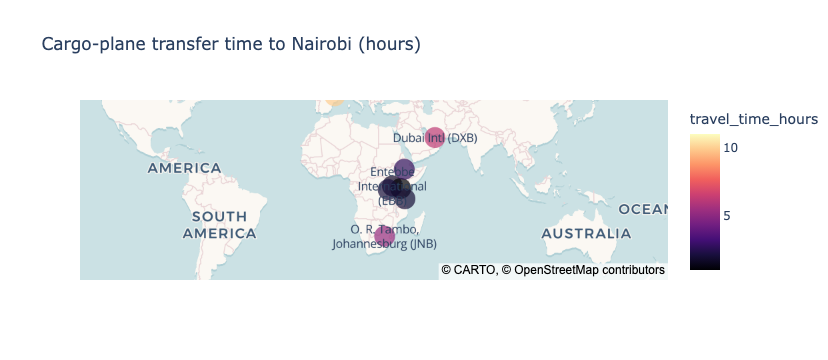

In [27]:
manager_agent.python_executor.state.get("fig")
